2026-07-05 08:49:39.918745: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1783241380.267538      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1783241380.371067      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1783241381.232568      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1783241381.232650      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1783241381.232657      57 computation_placer.cc:177] computation placer alr

 Caching and filtering slices (this takes time once)...


I0000 00:00:1783242442.332142      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1783242442.338405      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step

 STAGE 1: EASY SLICES
Epoch 1/5


I0000 00:00:1783242455.790990     129 service.cc:152] XLA service 0x7d0504002ac0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1783242455.791045     129 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1783242455.791051     129 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1783242457.698043     129 cuda_dnn.cc:529] Loaded cuDNN version 91002


  1/148 ━━━━━━━━━━━━━━━━━━━━ 34:45 14s/step - accuracy: 0.0625 - loss: 2.6284

I0000 00:00:1783242463.622358     129 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


148/148 ━━━━━━━━━━━━━━━━━━━━ 44s 203ms/step - accuracy: 0.6363 - loss: 1.6576 - val_accuracy: 0.6166 - val_loss: 1.0003
Epoch 2/5
148/148 ━━━━━━━━━━━━━━━━━━━━ 19s 129ms/step - accuracy: 0.7431 - loss: 0.6962 - val_accuracy: 0.6237 - val_loss: 1.0303
Epoch 3/5
148/148 ━━━━━━━━━━━━━━━━━━━━ 20s 134ms/step - accuracy: 0.7559 - loss: 0.6444 - val_accuracy: 0.6138 - val_loss: 1.1485

 STAGE 2: MEDIUM DIFFICULTY
Epoch 1/5
259/259 ━━━━━━━━━━━━━━━━━━━━ 37s 142ms/step - accuracy: 0.6944 - loss: 0.8154 - val_accuracy: 0.6336 - val_loss: 0.8286
Epoch 2/5
259/259 ━━━━━━━━━━━━━━━━━━━━ 35s 133ms/step - accuracy: 0.7272 - loss: 0.7062 - val_accuracy: 0.6941 - val_loss: 0.7338
Epoch 3/5
259/259 ━━━━━━━━━━━━━━━━━━━━ 33s 126ms/step - accuracy: 0.7491 - loss: 0.6596 - val_accuracy: 0.7063 - val_loss: 0.7283
Epoch 4/5
259/259 ━━━━━━━━━━━━━━━━━━━━ 33s 127ms/step - accuracy: 0.7691 - loss: 0.5945 - val_accuracy: 0.7348 - val_loss: 0.6899
Epoch 5/5
259/259 ━━━━━━━━━━━━━━━━━━━━ 34s 131ms/step - accuracy: 0.785

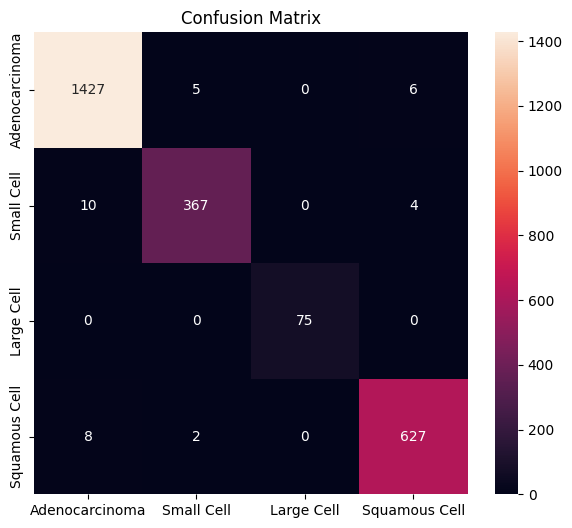


 FINAL TEST ACCURACY: 98.62%


In [1]:


import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import Sequence
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

import pydicom
from skimage import exposure
from PIL import Image
import warnings
warnings.filterwarnings("ignore")

#config

BASE_DIR = "/kaggle/input/lung-cancer-ct-pet-subset-dicom-format/imbalanced_dataset"
CACHE_DIR = "/kaggle/working/png_cache"

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

EPOCHS_EASY = 5
EPOCHS_MED = 5
EPOCHS_FINE = 10

LR_EASY = 1e-3
LR_FINE = 1e-4

CLASS_MAP = {"A": 0, "B": 1, "E": 2, "G": 3}
CLASS_NAMES = ["Adenocarcinoma", "Small Cell", "Large Cell", "Squamous Cell"]

os.makedirs(CACHE_DIR, exist_ok=True)
np.random.seed(42)
tf.random.set_seed(42)

#slice filtering
def slice_score(img_gray):
    return img_gray.std()

def is_informative_slice(img_gray, threshold=0.12):
    return slice_score(img_gray) > threshold

#dicom

def preprocess_and_cache():
    paths, labels, scores = [], [], []

    for cls, lbl in CLASS_MAP.items():
        folder = os.path.join(BASE_DIR, cls)
        for f in os.listdir(folder):
            if not f.endswith(".dcm"):
                continue

            dcm_path = os.path.join(folder, f)
            dcm = pydicom.dcmread(dcm_path)
            img = dcm.pixel_array.astype(np.float32)

            # CT lung window
            if dcm.Modality == "CT":
                wc, ww = -600, 1500
                img = np.clip(img, wc - ww // 2, wc + ww // 2)
                img = (img - img.min()) / (img.max() - img.min() + 1e-8)
            else:
                img = (img - img.min()) / (img.max() - img.min() + 1e-8)

            img_gray = img.copy()

            #  SLICE FILTERING (paper step)
            if not is_informative_slice(img_gray):
                continue

            score = slice_score(img_gray)

            # CLAHE
            img = exposure.equalize_adapthist(img, clip_limit=0.03)
            img = (img * 255).astype(np.uint8)

            # Convert ONCE to PIL
            img_pil = Image.fromarray(img).convert("RGB")
            img_pil = img_pil.resize(IMG_SIZE)

            cls_dir = os.path.join(CACHE_DIR, str(lbl))
            os.makedirs(cls_dir, exist_ok=True)

            png_path = os.path.join(cls_dir, f.replace(".dcm", ".png"))

            #  SAVE DIRECTLY (no Image.fromarray again)
            img_pil.save(png_path)

            paths.append(png_path)
            labels.append(lbl)
            scores.append(score)

    return np.array(paths), np.array(labels), np.array(scores)


print(" Caching and filtering slices (this takes time once)...")
X_all, y_all, scores_all = preprocess_and_cache()

#train/test split

X_train, X_temp, y_train, y_temp, s_train, s_temp = train_test_split(
    X_all, y_all, scores_all, test_size=0.3, stratify=y_all, random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42
)



def curriculum_subset(X, y, s, ratio):
    idx = np.argsort(s)[::-1]  # highest score = easiest
    cut = int(len(idx) * ratio)
    sel = idx[:cut]
    return X[sel], y[sel]



class PNGGenerator(Sequence):
    def __init__(self, paths, labels, augment=False):
        self.paths = paths
        self.labels = tf.keras.utils.to_categorical(labels, 4)
        self.augment = augment
        self.datagen = ImageDataGenerator(horizontal_flip=True)

    def __len__(self):
        return int(np.ceil(len(self.paths) / BATCH_SIZE))

    def __getitem__(self, idx):
        batch_paths = self.paths[idx*BATCH_SIZE:(idx+1)*BATCH_SIZE]
        batch_labels = self.labels[idx*BATCH_SIZE:(idx+1)*BATCH_SIZE]

        X = np.array([
            preprocess_input(np.array(Image.open(p)).astype(np.float32))
            for p in batch_paths
        ])

        if self.augment:
            X = np.array([self.datagen.random_transform(x) for x in X])

        return X, batch_labels

#RESNET 50
base = ResNet50(weights="imagenet", include_top=False, input_shape=(*IMG_SIZE, 3))
for layer in base.layers:
    layer.trainable = False

x = GlobalAveragePooling2D()(base.output)
x = Dense(512, activation="relu")(x)
x = Dropout(0.3)(x)
out = Dense(4, activation="softmax")(x)

model = Model(base.input, out)


print("\n STAGE 1: EASY SLICES")

Xe, ye = curriculum_subset(X_train, y_train, s_train, 0.4)

model.compile(
    optimizer=Adam(LR_EASY),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.fit(
    PNGGenerator(Xe, ye, augment=False),
    validation_data=PNGGenerator(X_val, y_val),
    epochs=EPOCHS_EASY,
    callbacks=[EarlyStopping(patience=2, restore_best_weights=True)]
)


print("\n STAGE 2: MEDIUM DIFFICULTY")

Xm, ym = curriculum_subset(X_train, y_train, s_train, 0.7)

model.fit(
    PNGGenerator(Xm, ym, augment=True),
    validation_data=PNGGenerator(X_val, y_val),
    epochs=EPOCHS_MED
)


print("\n STAGE 3: FINE TUNING")

for layer in base.layers[-30:]:
    layer.trainable = True

model.compile(
    optimizer=Adam(LR_FINE),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.fit(
    PNGGenerator(X_train, y_train, augment=True),
    validation_data=PNGGenerator(X_val, y_val),
    epochs=EPOCHS_FINE,
    callbacks=[
        ReduceLROnPlateau(patience=2, factor=0.5),
        EarlyStopping(patience=4, restore_best_weights=True)
    ]
)


test_gen = PNGGenerator(X_test, y_test)
pred = np.argmax(model.predict(test_gen), axis=1)

print("\n CLASSIFICATION REPORT\n")
print(classification_report(y_test, pred, target_names=CLASS_NAMES))

cm = confusion_matrix(y_test, pred)
plt.figure(figsize=(7,6))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=CLASS_NAMES,
            yticklabels=CLASS_NAMES)
plt.title("Confusion Matrix")
plt.show()

acc = np.mean(pred == y_test)
print(f"\n FINAL TEST ACCURACY: {acc*100:.2f}%")


DENSENET

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step

 DENSENET — STAGE 1: EASY
Epoch 1/5
369/369 ━━━━━━━━━━━━━━━━━━━━ 89s 170ms/step - accuracy: 0.6044 - loss: 1.0236 - val_accuracy: 0.7083 - val_loss: 0.7495
Epoch 2/5
369/369 ━━━━━━━━━━━━━━━━━━━━ 39s 107ms/step - accuracy: 0.6959 - loss: 0.7571 - val_accuracy: 0.7340 - val_loss: 0.6812
Epoch 3/5
369/369 ━━━━━━━━━━━━━━━━━━━━ 38s 103ms/step - accuracy: 0.7185 - loss: 0.6959 - val_accuracy: 0.7806 - val_loss: 0.5917
Epoch 4/5
369/369 ━━━━━━━━━━━━━━━━━━━━ 39s 105ms/step - accuracy: 0.7473 - loss: 0.6257 - val_accuracy: 0.7834 - val_loss: 0.5403
Epoch 5/5
369/369 ━━━━━━━━━━━━━━━━━━━━ 38s 104ms/step - accuracy: 0.7648 - loss: 0.5941 - val_accuracy: 0.8004 - val_loss: 0.5120

 DENSENET — STAGE 2: MEDIUM
Epoch 1/5
369/369 ━━━━━━━━━━━━━━━━━━━━ 38s 104ms/step - accuracy: 0.7708 - loss: 0.5717 - val_accuracy: 0.8055 - val_loss: 0.4990
Epoch 2/5
369/369 ━━━━━━━━━━━━━━━━━━━━ 38s 103ms/step - accuracy: 0.7877 - loss: 0.5456 - val_accuracy: 0.8241 - 

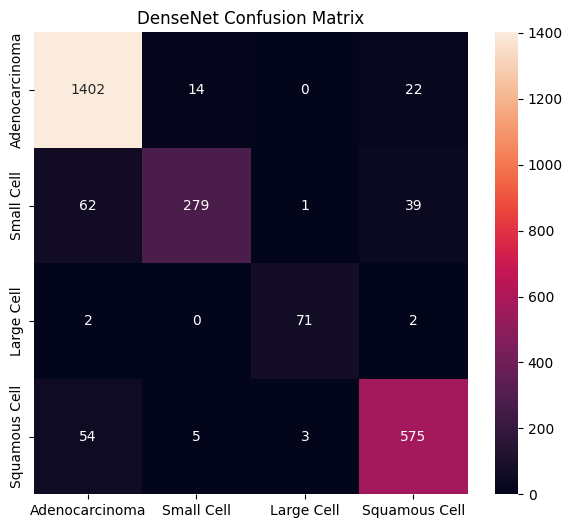


DENSENET FINAL TEST ACCURACY: 91.94%


In [2]:
import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.applications.densenet import preprocess_input
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import Sequence
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from PIL import Image
import warnings
warnings.filterwarnings("ignore")


CACHE_DIR = "/kaggle/working/png_cache"
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

EPOCHS_EASY = 5
EPOCHS_MED = 5
EPOCHS_FINE = 8

LR_EASY = 1e-3
LR_FINE = 5e-5

CLASS_NAMES = ["Adenocarcinoma", "Small Cell", "Large Cell", "Squamous Cell"]

np.random.seed(42)
tf.random.set_seed(42)


def load_cached_data(cache_dir):
    paths, labels = [], []

    for lbl in range(4):
        folder = os.path.join(cache_dir, str(lbl))
        for f in os.listdir(folder):
            if f.endswith(".png"):
                paths.append(os.path.join(folder, f))
                labels.append(lbl)

    return np.array(paths), np.array(labels)

X_all, y_all = load_cached_data(CACHE_DIR)


X_train, X_temp, y_train, y_temp = train_test_split(
    X_all, y_all, test_size=0.3, stratify=y_all, random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42
)


class PNGGenerator(Sequence):
    def __init__(self, paths, labels, augment=False):
        self.paths = paths
        self.labels = tf.keras.utils.to_categorical(labels, 4)
        self.augment = augment
        self.datagen = ImageDataGenerator(horizontal_flip=True)

    def __len__(self):
        return int(np.ceil(len(self.paths) / BATCH_SIZE))

    def __getitem__(self, idx):
        batch_paths = self.paths[idx*BATCH_SIZE:(idx+1)*BATCH_SIZE]
        batch_labels = self.labels[idx*BATCH_SIZE:(idx+1)*BATCH_SIZE]

        X = np.array([
            preprocess_input(np.array(Image.open(p)).astype(np.float32))
            for p in batch_paths
        ])

        if self.augment:
            X = np.array([self.datagen.random_transform(x) for x in X])

        return X, batch_labels


base = DenseNet121(
    weights="imagenet",
    include_top=False,
    input_shape=(*IMG_SIZE, 3)
)

# Stage 1: fully frozen
for layer in base.layers:
    layer.trainable = False

x = GlobalAveragePooling2D()(base.output)
x = Dense(256, activation="relu")(x)
x = Dropout(0.4)(x)
out = Dense(4, activation="softmax")(x)

model = Model(base.input, out)


print("\n DENSENET — STAGE 1: EASY")

model.compile(
    optimizer=Adam(LR_EASY),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.fit(
    PNGGenerator(X_train, y_train, augment=False),
    validation_data=PNGGenerator(X_val, y_val),
    epochs=EPOCHS_EASY,
    callbacks=[EarlyStopping(patience=2, restore_best_weights=True)]
)


print("\n DENSENET — STAGE 2: MEDIUM")

model.fit(
    PNGGenerator(X_train, y_train, augment=True),
    validation_data=PNGGenerator(X_val, y_val),
    epochs=EPOCHS_MED
)


print("\n DENSENET — STAGE 3: FINE TUNING")

for layer in base.layers[-20:]:
    layer.trainable = True

model.compile(
    optimizer=Adam(LR_FINE),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.fit(
    PNGGenerator(X_train, y_train, augment=True),
    validation_data=PNGGenerator(X_val, y_val),
    epochs=EPOCHS_FINE,
    callbacks=[
        ReduceLROnPlateau(patience=2, factor=0.5),
        EarlyStopping(patience=3, restore_best_weights=True)
    ]
)


pred = np.argmax(model.predict(PNGGenerator(X_test, y_test)), axis=1)

print("\n CLASSIFICATION REPORT (DenseNet)\n")
print(classification_report(y_test, pred, target_names=CLASS_NAMES))

cm = confusion_matrix(y_test, pred)
plt.figure(figsize=(7,6))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=CLASS_NAMES,
            yticklabels=CLASS_NAMES)
plt.title("DenseNet Confusion Matrix")
plt.show()

acc = np.mean(pred == y_test)
print(f"\nDENSENET FINAL TEST ACCURACY: {acc*100:.2f}%")


Total images loaded: 16869
58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step

 VGG16 — STAGE 1
Epoch 1/5
369/369 ━━━━━━━━━━━━━━━━━━━━ 119s 266ms/step - accuracy: 0.5928 - loss: 1.7267 - val_accuracy: 0.7605 - val_loss: 0.6320
Epoch 2/5
369/369 ━━━━━━━━━━━━━━━━━━━━ 93s 253ms/step - accuracy: 0.7319 - loss: 0.6860 - val_accuracy: 0.7605 - val_loss: 0.5822
Epoch 3/5
369/369 ━━━━━━━━━━━━━━━━━━━━ 94s 255ms/step - accuracy: 0.7655 - loss: 0.6091 - val_accuracy: 0.8261 - val_loss: 0.4665
Epoch 4/5
369/369 ━━━━━━━━━━━━━━━━━━━━ 93s 252ms/step - accuracy: 0.7941 - loss: 0.5157 - val_accuracy: 0.8470 - val_loss: 0.4419
Epoch 5/5
369/369 ━━━━━━━━━━━━━━━━━━━━ 94s 254ms/step - accuracy: 0.8179 - loss: 0.4704 - val_accuracy: 0.8360 - val_loss: 0.4324

 VGG16 — STAGE 2
Epoch 1/5
369/369 ━━━━━━━━━━━━━━━━━━━━ 153s 415ms/step - accuracy: 0.7658 - loss: 0.6007 - val_accuracy: 0.8419 - val_loss: 0.4239
Epoch 2/5
369/369 ━━━━━━━━━━━━━━━━━━━━ 154s 417ms/step - accuracy: 0.7886 - loss: 0.5340 - val_accuracy:

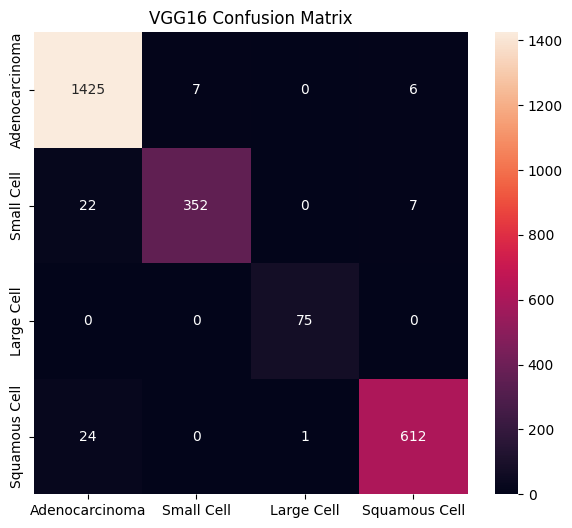


 VGG16 FINAL TEST ACCURACY: 97.35%


In [3]:

import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import Sequence
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from PIL import Image
import warnings
warnings.filterwarnings("ignore")


CACHE_DIR = "/kaggle/working/png_cache"   # ✅ UPDATED PATH

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

EPOCHS_EASY = 5
EPOCHS_MED = 5
EPOCHS_FINE = 10

LR_EASY = 1e-3
LR_FINE = 1e-5

CLASS_NAMES = ["Adenocarcinoma", "Small Cell", "Large Cell", "Squamous Cell"]

np.random.seed(42)
tf.random.set_seed(42)


def load_cached_data(cache_dir):
    paths, labels = [], []

    for lbl in range(4):
        folder = os.path.join(cache_dir, str(lbl))

        if not os.path.exists(folder):
            print(f"Missing folder: {folder}")
            continue

        for f in os.listdir(folder):
            if f.endswith(".png"):
                paths.append(os.path.join(folder, f))
                labels.append(lbl)

    return np.array(paths), np.array(labels)

X_all, y_all = load_cached_data(CACHE_DIR)

print("Total images loaded:", len(X_all))


X_train, X_temp, y_train, y_temp = train_test_split(
    X_all, y_all, test_size=0.3, stratify=y_all, random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42
)


class PNGGenerator(Sequence):

    def __init__(self, paths, labels, augment=False):
        self.paths = paths
        self.labels = tf.keras.utils.to_categorical(labels, 4)
        self.augment = augment
        self.datagen = ImageDataGenerator(
            horizontal_flip=True,
            rotation_range=10
        )

    def __len__(self):
        return int(np.ceil(len(self.paths) / BATCH_SIZE))

    def __getitem__(self, idx):

        batch_paths = self.paths[idx*BATCH_SIZE:(idx+1)*BATCH_SIZE]
        batch_labels = self.labels[idx*BATCH_SIZE:(idx+1)*BATCH_SIZE]

        X = np.array([
            preprocess_input(
                np.array(Image.open(p)).astype(np.float32)
            )
            for p in batch_paths
        ])

        if self.augment:
            X = np.array([self.datagen.random_transform(x) for x in X])

        return X, batch_labels


base = VGG16(
    weights="imagenet",
    include_top=False,
    input_shape=(*IMG_SIZE, 3)
)

# Freeze backbone
for layer in base.layers:
    layer.trainable = False

x = GlobalAveragePooling2D()(base.output)
x = Dense(512, activation="relu")(x)
x = Dropout(0.5)(x)
out = Dense(4, activation="softmax")(x)

model = Model(base.input, out)


print("\n VGG16 — STAGE 1")

model.compile(
    optimizer=Adam(LR_EASY),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.fit(
    PNGGenerator(X_train, y_train, augment=False),
    validation_data=PNGGenerator(X_val, y_val),
    epochs=EPOCHS_EASY,
    callbacks=[EarlyStopping(patience=2, restore_best_weights=True)]
)


print("\n VGG16 — STAGE 2")

model.fit(
    PNGGenerator(X_train, y_train, augment=True),
    validation_data=PNGGenerator(X_val, y_val),
    epochs=EPOCHS_MED
)


print("\n VGG16 — STAGE 3")

for layer in base.layers[-8:]:
    layer.trainable = True

model.compile(
    optimizer=Adam(LR_FINE),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.fit(
    PNGGenerator(X_train, y_train, augment=True),
    validation_data=PNGGenerator(X_val, y_val),
    epochs=EPOCHS_FINE,
    callbacks=[
        ReduceLROnPlateau(patience=2, factor=0.5),
        EarlyStopping(patience=4, restore_best_weights=True)
    ]
)


pred = np.argmax(model.predict(PNGGenerator(X_test, y_test)), axis=1)

print("\n CLASSIFICATION REPORT (VGG16)\n")
print(classification_report(y_test, pred, target_names=CLASS_NAMES))

cm = confusion_matrix(y_test, pred)

plt.figure(figsize=(7,6))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=CLASS_NAMES,
            yticklabels=CLASS_NAMES)
plt.title("VGG16 Confusion Matrix")
plt.show()

acc = np.mean(pred == y_test)
print(f"\n VGG16 FINAL TEST ACCURACY: {acc*100:.2f}%")


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Epoch 1/5


2026-07-05 10:24:50.211537: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-05 10:24:50.350036: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


369/369 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.6391 - loss: 0.9693

2026-07-05 10:25:27.644318: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-05 10:25:27.780893: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


369/369 ━━━━━━━━━━━━━━━━━━━━ 53s 101ms/step - accuracy: 0.6392 - loss: 0.9689 - val_accuracy: 0.7281 - val_loss: 0.6710
Epoch 2/5
369/369 ━━━━━━━━━━━━━━━━━━━━ 25s 67ms/step - accuracy: 0.7645 - loss: 0.6061 - val_accuracy: 0.7838 - val_loss: 0.5499
Epoch 3/5
369/369 ━━━━━━━━━━━━━━━━━━━━ 24s 66ms/step - accuracy: 0.7976 - loss: 0.5226 - val_accuracy: 0.8332 - val_loss: 0.4436
Epoch 4/5
369/369 ━━━━━━━━━━━━━━━━━━━━ 25s 68ms/step - accuracy: 0.8286 - loss: 0.4471 - val_accuracy: 0.8490 - val_loss: 0.3954
Epoch 5/5
369/369 ━━━━━━━━━━━━━━━━━━━━ 25s 68ms/step - accuracy: 0.8540 - loss: 0.3730 - val_accuracy: 0.8415 - val_loss: 0.4084
Epoch 1/5
369/369 ━━━━━━━━━━━━━━━━━━━━ 33s 91ms/step - accuracy: 0.8437 - loss: 0.4000 - val_accuracy: 0.8502 - val_loss: 0.3835
Epoch 2/5
369/369 ━━━━━━━━━━━━━━━━━━━━ 29s 79ms/step - accuracy: 0.8575 - loss: 0.3615 - val_accuracy: 0.8613 - val_loss: 0.3525
Epoch 3/5
369/369 ━━━━━━━━━━━━━━━━━━━━ 29s 80ms/step - accuracy: 0.8692 - loss: 0.3384 - val_accuracy: 0.8

2026-07-05 10:34:24.548722: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-05 10:34:24.685230: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


80/80 ━━━━━━━━━━━━━━━━━━━━ 18s 176ms/step
                precision    recall  f1-score   support

Adenocarcinoma       0.94      0.99      0.96      1438
    Small Cell       0.98      0.85      0.91       381
    Large Cell       0.96      1.00      0.98        75
 Squamous Cell       0.96      0.92      0.94       637

      accuracy                           0.95      2531
     macro avg       0.96      0.94      0.95      2531
  weighted avg       0.95      0.95      0.95      2531



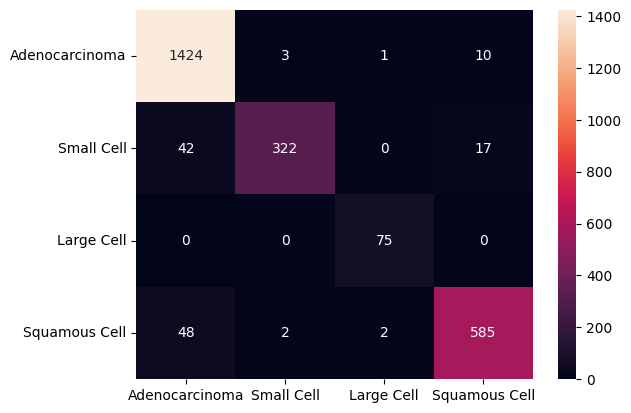

MobileNetV2 Accuracy: 95.06124061635717


In [4]:
# MOBILENETV2 LUNG CANCER CLASSIFICATION


import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import Sequence
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from PIL import Image

# CONFIG


CACHE_DIR = "/kaggle/working/png_cache"
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

EPOCHS_EASY = 5
EPOCHS_MED = 5
EPOCHS_FINE = 8

LR_EASY = 1e-3
LR_FINE = 3e-5

CLASS_NAMES = ["Adenocarcinoma","Small Cell","Large Cell","Squamous Cell"]

 
# LOAD DATA
 

def load_cached_data(cache_dir):
    paths, labels = [], []
    for lbl in range(4):
        folder = os.path.join(cache_dir, str(lbl))
        for f in os.listdir(folder):
            if f.endswith(".png"):
                paths.append(os.path.join(folder,f))
                labels.append(lbl)
    return np.array(paths), np.array(labels)

X_all, y_all = load_cached_data(CACHE_DIR)

X_train, X_temp, y_train, y_temp = train_test_split(
    X_all, y_all, test_size=0.3, stratify=y_all, random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42
)

 
# GENERATOR
 

class PNGGenerator(Sequence):

    def __init__(self, paths, labels, augment=False):
        self.paths = paths
        self.labels = tf.keras.utils.to_categorical(labels,4)
        self.augment = augment
        self.datagen = ImageDataGenerator(horizontal_flip=True)

    def __len__(self):
        return int(np.ceil(len(self.paths)/BATCH_SIZE))

    def __getitem__(self, idx):

        batch_paths = self.paths[idx*BATCH_SIZE:(idx+1)*BATCH_SIZE]
        batch_labels = self.labels[idx*BATCH_SIZE:(idx+1)*BATCH_SIZE]

        X = np.array([
            preprocess_input(np.array(Image.open(p)).astype(np.float32))
            for p in batch_paths
        ])

        if self.augment:
            X = np.array([self.datagen.random_transform(x) for x in X])

        return X, batch_labels

 
# MODEL — MobileNetV2
 

base = MobileNetV2(weights="imagenet",
                   include_top=False,
                   input_shape=(*IMG_SIZE,3))

for layer in base.layers:
    layer.trainable = False

x = GlobalAveragePooling2D()(base.output)
x = Dense(256, activation="relu")(x)
x = Dropout(0.3)(x)
out = Dense(4, activation="softmax")(x)

model = Model(base.input, out)


model.compile(optimizer=Adam(LR_EASY),
              loss="categorical_crossentropy",
              metrics=["accuracy"])

model.fit(
    PNGGenerator(X_train,y_train,False),
    validation_data=PNGGenerator(X_val,y_val),
    epochs=EPOCHS_EASY,
    callbacks=[EarlyStopping(patience=2,restore_best_weights=True)]
)


model.fit(
    PNGGenerator(X_train,y_train,True),
    validation_data=PNGGenerator(X_val,y_val),
    epochs=EPOCHS_MED
)

  
for layer in base.layers[-20:]:
    layer.trainable=True

model.compile(optimizer=Adam(LR_FINE),
              loss="categorical_crossentropy",
              metrics=["accuracy"])

model.fit(
    PNGGenerator(X_train,y_train,True),
    validation_data=PNGGenerator(X_val,y_val),
    epochs=EPOCHS_FINE,
    callbacks=[
        ReduceLROnPlateau(patience=2,factor=0.5),
        EarlyStopping(patience=3,restore_best_weights=True)
])

#    EVALUATION   

pred=np.argmax(model.predict(PNGGenerator(X_test,y_test)),axis=1)

print(classification_report(y_test,pred,target_names=CLASS_NAMES))

cm=confusion_matrix(y_test,pred)
sns.heatmap(cm,annot=True,fmt="d",
            xticklabels=CLASS_NAMES,
            yticklabels=CLASS_NAMES)
plt.show()

print("MobileNetV2 Accuracy:",
      np.mean(pred==y_test)*100)


171446536/171446536 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step
Epoch 1/5
369/369 ━━━━━━━━━━━━━━━━━━━━ 108s 248ms/step - accuracy: 0.6175 - loss: 1.1374 - val_accuracy: 0.7411 - val_loss: 0.6568
Epoch 2/5
369/369 ━━━━━━━━━━━━━━━━━━━━ 82s 221ms/step - accuracy: 0.7480 - loss: 0.6285 - val_accuracy: 0.7941 - val_loss: 0.5233
Epoch 3/5
369/369 ━━━━━━━━━━━━━━━━━━━━ 81s 219ms/step - accuracy: 0.7931 - loss: 0.5382 - val_accuracy: 0.8213 - val_loss: 0.4541
Epoch 4/5
369/369 ━━━━━━━━━━━━━━━━━━━━ 81s 218ms/step - accuracy: 0.8130 - loss: 0.4856 - val_accuracy: 0.8138 - val_loss: 0.4709
Epoch 5/5
369/369 ━━━━━━━━━━━━━━━━━━━━ 82s 221ms/step - accuracy: 0.8387 - loss: 0.4138 - val_accuracy: 0.8538 - val_loss: 0.3864
Epoch 1/5
369/369 ━━━━━━━━━━━━━━━━━━━━ 81s 219ms/step - accuracy: 0.8336 - loss: 0.4362 - val_accuracy: 0.8664 - val_loss: 0.3452
Epoch 2/5
369/369 ━━━━━━━━━━━━━━━━━━━━ 81s 220ms/step - accuracy: 0.8475 - loss: 0.3951 - val_accuracy: 0.8542 - val_loss: 0.3672
Epoch 3/5
369/369 ━━━━━━━━━━━━━━━━━━

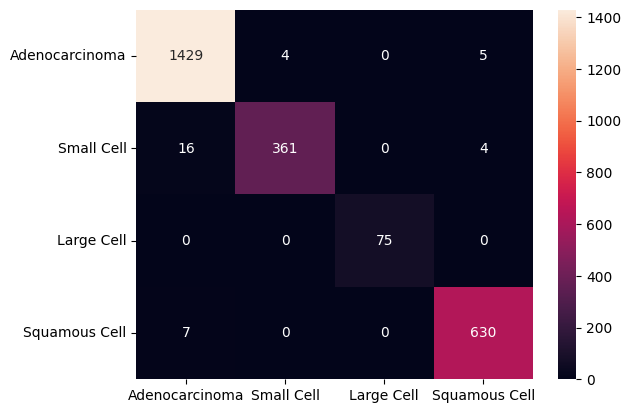

ResNet101 Accuracy: 98.57763729751086


In [5]:
 
# RESNET101 LUNG CANCER CLASSIFICATION
 

from tensorflow.keras.applications import ResNet101
from tensorflow.keras.applications.resnet import preprocess_input

# MODEL
base = ResNet101(
    weights="imagenet",
    include_top=False,
    input_shape=(*IMG_SIZE,3)
)

for layer in base.layers:
    layer.trainable=False

x = GlobalAveragePooling2D()(base.output)
x = Dense(512,activation="relu")(x)
x = Dropout(0.3)(x)
out = Dense(4,activation="softmax")(x)

model = Model(base.input,out)

#    STAGE 1   
model.compile(
    optimizer=Adam(1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.fit(
    PNGGenerator(X_train,y_train,False),
    validation_data=PNGGenerator(X_val,y_val),
    epochs=5,
    callbacks=[EarlyStopping(patience=2,restore_best_weights=True)]
)

#    STAGE 2   
model.fit(
    PNGGenerator(X_train,y_train,True),
    validation_data=PNGGenerator(X_val,y_val),
    epochs=5
)

#    STAGE 3 (Fine Tune)   
for layer in base.layers[-40:]:
    layer.trainable=True

model.compile(
    optimizer=Adam(1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.fit(
    PNGGenerator(X_train,y_train,True),
    validation_data=PNGGenerator(X_val,y_val),
    epochs=10,
    callbacks=[
        ReduceLROnPlateau(patience=2,factor=0.5),
        EarlyStopping(patience=4,restore_best_weights=True)
])

#    EVALUATION   
pred=np.argmax(model.predict(PNGGenerator(X_test,y_test)),axis=1)

print(classification_report(y_test,pred,target_names=CLASS_NAMES))

cm=confusion_matrix(y_test,pred)
sns.heatmap(cm,annot=True,fmt="d",
            xticklabels=CLASS_NAMES,
            yticklabels=CLASS_NAMES)
plt.show()

print("ResNet101 Accuracy:",
      np.mean(pred==y_test)*100)
